In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

In [4]:
#%env PYTHONWARNINGS=error

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(alpha=0.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True, n_splits=10),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1)	score: 0.6943
Trying rank (2, 2)	score: 0.6944
Trying rank (4, 4)	score: 0.6961
Trying rank (8, 8)	score: 0.7255
Trying rank (8, 16)	score: 0.7460
Trying rank (8, 32)	score: 0.7774
Trying rank (8, 48)	score: 0.7881

Selected rank (8, 48) with score 0.7881
New ranks: [(8, 48)]


Model selection block 2/4...

Trying rank (1, 1)	score: 0.7861
Trying rank (2, 2)	score: 0.7879
Trying rank (4, 4)	score: 0.7885
Trying rank (8, 8)	score: 0.7918
Trying rank (8, 16)	score: 0.7913
Trying rank (8, 32)	score: 0.7959
Trying rank (8, 48)	score: 0.7969

Selected rank (8, 48) with score 0.7969
New ranks: [(8, 48), (8, 48)]


Model selection block 3/4...

Trying rank (1, 1)	score: 0.7965
Trying rank (2, 2)	score: 0.7969
Trying rank (4, 4)	score: 0.7974
Trying rank (8, 8)	score: 0.7986
Trying rank (8, 16)	score: 0.8008
Trying rank (8, 32)	score: 0.8000
Trying rank (8, 48)	score: 0.8023

Selected rank (8, 48) with score 0.8023
New ranks: [(8, 48), (8, 48), 

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF(alpha=0.05)),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function CupyBackend.to_numpy at 0x7fe509a988b0>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (8, 48), 'shrinkage': 'lw',
                         'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                         'tol': 1e-08, 'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [6]:
bttda.model_select_info_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (1, 1)      0     0.740471   0.638903           1    0.698827
      (1, 1)      1     0.735141   0.680995           1    0.696510
      (1, 1)      2     0.739205   0.629911           1    0.692071
      (1, 1)      3     0.732992   0.703699           1    0.699153
      (1, 1)      4     0.723249   0.757781           1    0.693663
...             ...          ...        ...         ...         ...
3     (8, 48)     5     0.875857   0.835651        1536    0.825010
      (8, 48)     6     0.883156   0.788584        1536    0.797000
      (8, 48)     7     0.884181   0.796811        1536    0.801071
      (8, 48)     8     0.877988   0.836862        1536    0.809408
      (8, 48)     9     0.878397   0.823406        1536    0.799214

[280 rows x 5 columns]

In [7]:
bttda.model_select_info_best_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (8, 48)     0     0.844630   0.797640         384    0.812949
      (8, 48)     1     0.853794   0.757462         384    0.796653
      (8, 48)     2     0.853849   0.698724         384    0.780071
      (8, 48)     3     0.847898   0.796747         384    0.797816
      (8, 48)     4     0.847704   0.833418         384    0.797735
      (8, 48)     5     0.831228   0.836097         384    0.791327
      (8, 48)     6     0.840572   0.761990         384    0.774469
      (8, 48)     7     0.845377   0.783865         384    0.777245
      (8, 48)     8     0.844743   0.796875         384    0.789286
      (8, 48)     9     0.843112   0.817793         384    0.789755
1     (8, 48)     0     0.867416   0.805676         768    0.825714
      (8, 48)     1     0.872516   0.775191         768    0.814653
      (8, 48)     2     0.874432   0.702041         768    0.792929
      (8, 48)     3     0.868319   0.810714         768    0.805969
      (8, 48)     4     0.863574   0.837372         768    0.811286
      (8, 48)     5     0.860327   0.832972         768    0.821459
      (8, 48)     6     0.865540   0.767857         768    0.791929
      (8, 48)     7     0.868734   0.796429         768    0.794082
      (8, 48)     8     0.865653   0.818367         768    0.803429
      (8, 48)     9     0.862807   0.822258         768    0.800235
2     (8, 48)     0     0.874494   0.807972        1152    0.821724
      (8, 48)     1     0.878407   0.786798        1152    0.820327
      (8, 48)     2     0.882109   0.714732        1152    0.798806
      (8, 48)     3     0.874626   0.815944        1152    0.808602
      (8, 48)     4     0.873324   0.835459        1152    0.810398
      (8, 48)     5     0.868874   0.832334        1152    0.822755
      (8, 48)     6     0.876440   0.771556        1152    0.797286
      (8, 48)     7     0.878371   0.796237        1152    0.806378
      (8, 48)     8     0.872652   0.835523        1152    0.807031
      (8, 48)     9     0.870711   0.826594        1152    0.801214
3     (8, 48)     0     0.881685   0.799043        1536    0.814990
      (8, 48)     1     0.885487   0.794388        1536    0.813316
      (8, 48)     2     0.888219   0.726913        1536    0.798735
      (8, 48)     3     0.879582   0.816263        1536    0.814265
      (8, 48)     4     0.879142   0.836862        1536    0.813500
      (8, 48)     5     0.875857   0.835651        1536    0.825010
      (8, 48)     6     0.883156   0.788584        1536    0.797000
      (8, 48)     7     0.884181   0.796811        1536    0.801071
      (8, 48)     8     0.877988   0.836862        1536    0.809408
      (8, 48)     9     0.878397   0.823406        1536    0.799214

In [8]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['val_score'].aggregate('mean')

block  rank   
0      (8, 48)    0.788061
1      (8, 48)    0.796888
2      (8, 48)    0.802315
3      (8, 48)    0.805478
Name: val_score, dtype: float64

In [9]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['test_score'].aggregate('mean')

block  rank   
0      (8, 48)    0.790731
1      (8, 48)    0.806168
2      (8, 48)    0.809452
3      (8, 48)    0.808651
Name: test_score, dtype: float64

block  rank  
0      (1, 1)    0.807051
1      (8, 8)    0.820216
2      (8, 8)    0.825298
3      (8, 8)    0.828784
4      (4, 4)    0.829647
5      (8, 8)    0.832404
6      (8, 8)    0.834165
7      (4, 4)    0.835178
Name: val_score, dtype: float64

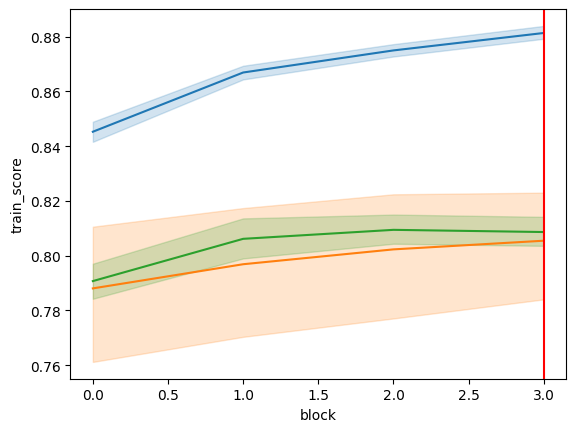

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.style.use('default')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='train_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='val_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='test_score')
plt.axvline(bttda.n_blocks_-1, color='red')

<Axes: xlabel='block', ylabel='n_features'>

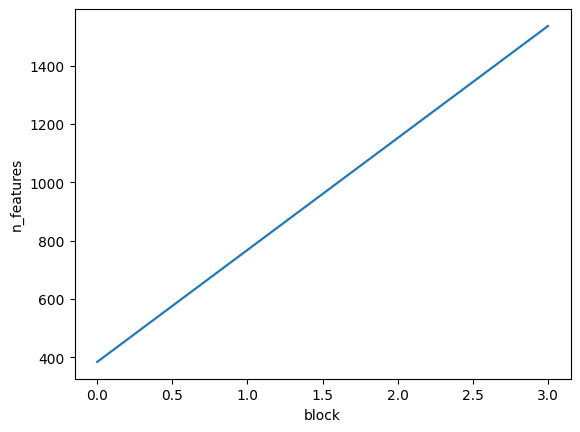

In [11]:
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='n_features')
